In [25]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import skimage.metrics as metrics
cv2.useOptimized() 
import urllib.request

/var/folders/n3/w2kc2s3d6t76l6jbt7gd52tc0000gn/T/ipykernel_95972/276478107.py:13: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(imgray.ravel(),256,[0,256])


Text(0.5, 1.0, 'Histogram of Grayscale Image')

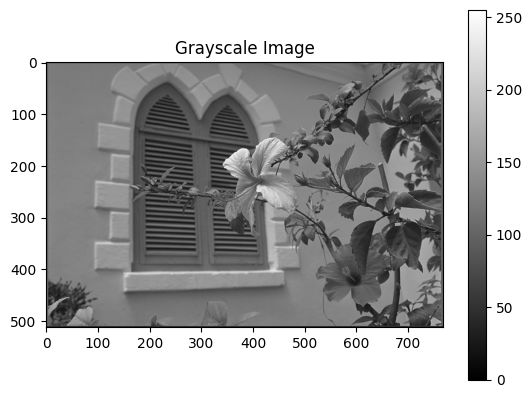

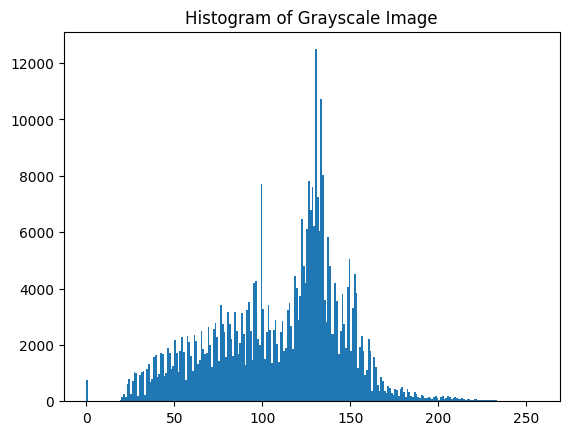

In [26]:
# read sample image from url

im=cv2.imread('./data/kodim07.png')
im=cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
imgray=cv2.cvtColor(im, cv2.COLOR_RGB2GRAY)
plt.figure()
plt.imshow(imgray, cmap='gray')
plt.colorbar()
plt.title('Grayscale Image')

#plot image istogram 
plt.figure()
plt.hist(imgray.ravel(),256,[0,256])
plt.title('Histogram of Grayscale Image')


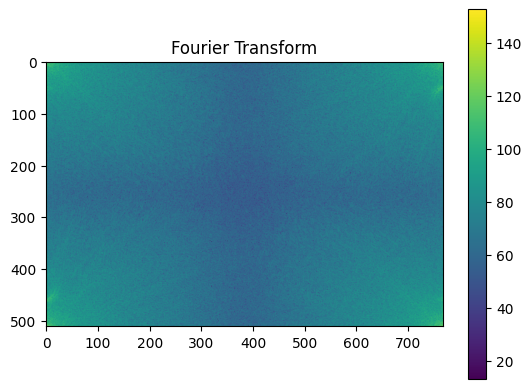

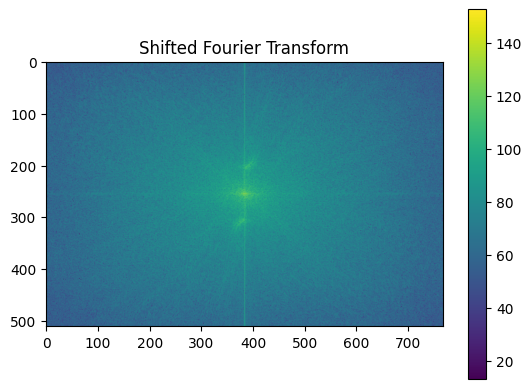

In [27]:
#implement DFT2d

#fft along rows
F2d_rows=np.fft.fft(imgray, axis=1)
#fft along columns
F2d_cols_rows=np.fft.fft(F2d_rows, axis=0)

plt.figure()
plt.imshow(20*np.log10(np.abs(F2d_cols_rows)))
plt.title('Fourier Transform')
plt.colorbar()

F2d_shifted=np.fft.fftshift(F2d_cols_rows)
plt.figure()    
plt.imshow(20*np.log10(np.abs(F2d_shifted)))
plt.title('Shifted Fourier Transform')
plt.colorbar()

/var/folders/n3/w2kc2s3d6t76l6jbt7gd52tc0000gn/T/ipykernel_95972/1924982993.py:18: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(20*np.log10(np.abs(F2d_filtered)))


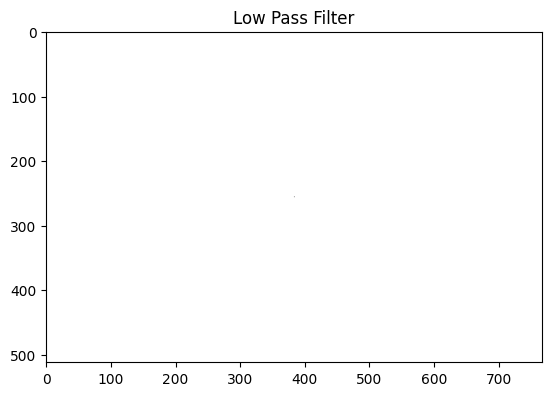

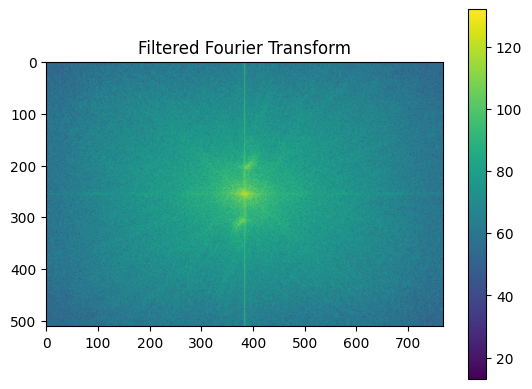

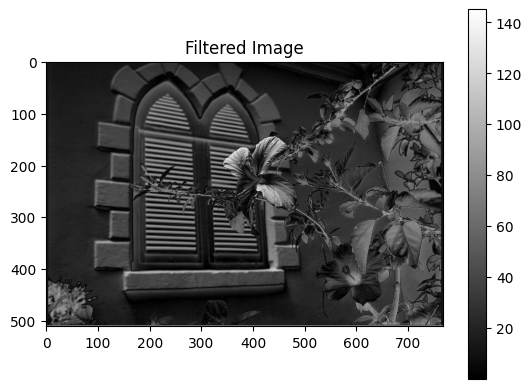

In [28]:
# simple convolutional filtering in the frequency domain
# create a low pass filter
rows, cols = imgray.shape
crow, ccol = rows//2 , cols//2
H = np.ones((rows, cols), np.uint8)
H[crow, ccol] = 0

# plot the filter
plt.figure()
plt.imshow(H, cmap='gray')
plt.title('Low Pass Filter')

# apply the filter in the frequency domain
F2d_filtered = F2d_shifted * H

# plot the filtered Fourier transform
plt.figure()
plt.imshow(20*np.log10(np.abs(F2d_filtered)))
plt.title('Filtered Fourier Transform')
plt.colorbar()


# inverse shift and inverse DFT
F2d_filtered_ishift = np.fft.ifftshift(F2d_filtered)
im_filtered = np.fft.ifft2(F2d_filtered_ishift)
im_filtered = np.abs(im_filtered)


# plot the filtered image
plt.figure()
plt.imshow(im_filtered, cmap='gray')
plt.title('Filtered Image')
plt.colorbar()



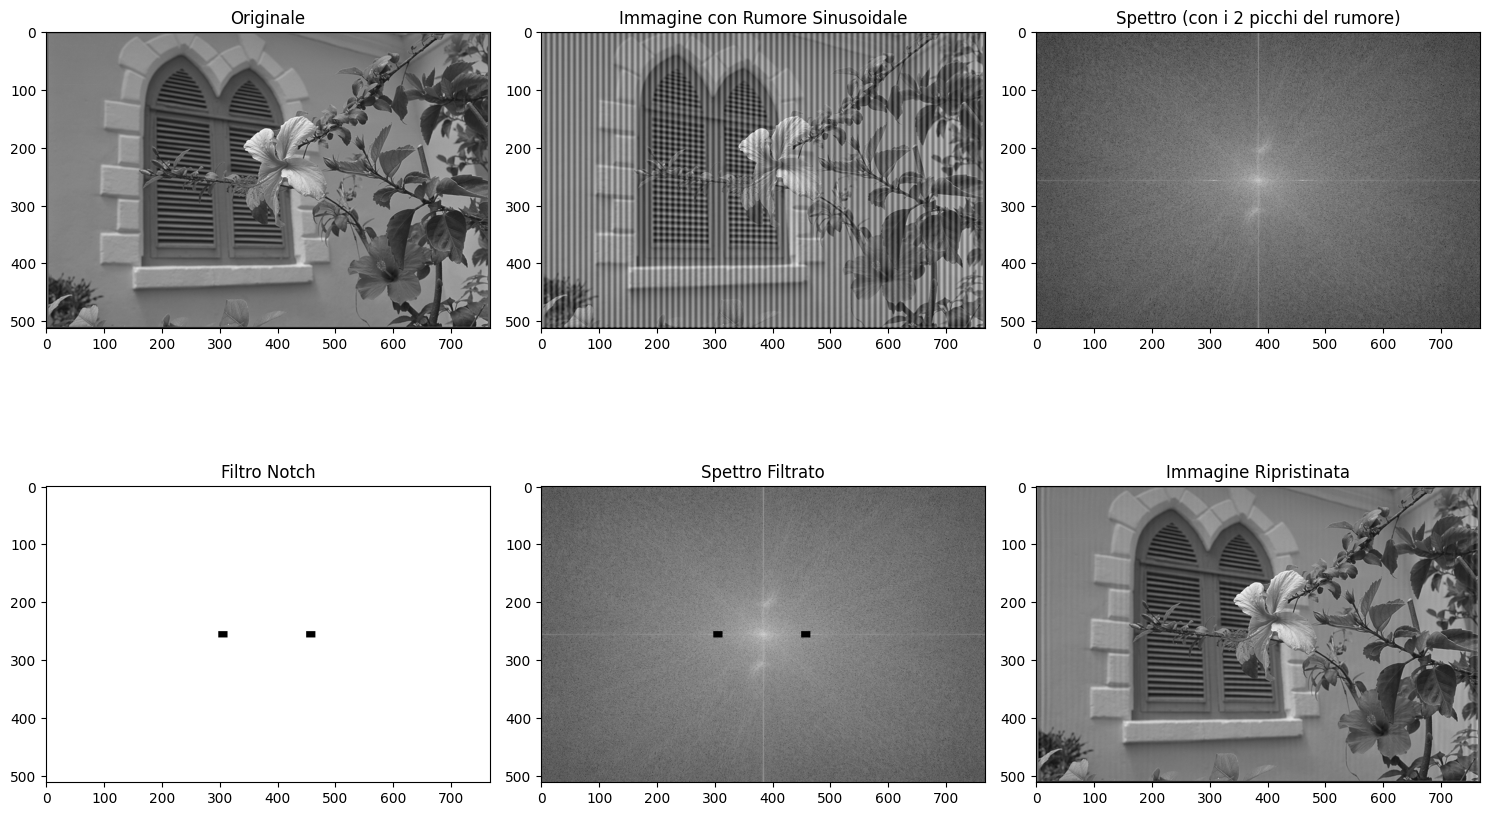

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Parametri del rumore
f_noise = 1/10  # Frequenza: 1 ciclo ogni 10 pixel
A = 50          # Ampiezza del rumore 

# 2. Generazione dell'immagine con rumore
# Assumiamo che imgray sia già definita (come da summary del notebook)
rows, cols = imgray.shape
x = np.arange(cols)
sin_noise = A * np.sin(2 * np.pi * f_noise * x)
noise_matrix = np.tile(sin_noise, (rows, 1))
img_noisy = imgray + noise_matrix

# 3. Trasformata di Fourier dell'immagine corrotta
F_noisy = np.fft.fft2(img_noisy)
F_shifted = np.fft.fftshift(F_noisy)
magnitude_spectrum = 20 * np.log(np.abs(F_shifted) + 1)

# 4. Creazione del Filtro Notch (Elimina-banda)
# La sinusoide orizzontale crea due picchi sull'asse delle frequenze orizzontali (u)
# passanti per il centro (crow, ccol).
# La distanza dal centro è u = f_noise * cols
crow, ccol = rows // 2, cols // 2
u_dist = int(f_noise * cols)

# Creiamo una maschera (1 dove passa, 0 dove blocca)
H = np.ones((rows, cols), dtype=np.float32)

# Definiamo un raggio per il filtro notch per essere sicuri di prendere il picco
r = 5  # raggio del filtro notch

H[crow-r : crow + r + 1, ccol + u_dist - r - 5 : ccol + u_dist + r + 1] = 0
H[crow-r : crow + r + 1, ccol - u_dist - r - 5: ccol - u_dist + r + 1] = 0

# 5. Applicazione del filtro e antitrasformata
F_filtered = F_shifted * H
F_ishift = np.fft.ifftshift(F_filtered)
img_back = np.fft.ifft2(F_ishift)
img_back = np.abs(img_back)

# 6. Visualizzazione
plt.figure(figsize=(15, 10))

plt.subplot(231), plt.imshow(imgray, cmap='gray'), plt.title('Originale')
plt.subplot(232), plt.imshow(img_noisy, cmap='gray'), plt.title('Immagine con Rumore Sinusoidale')
plt.subplot(233), plt.imshow(magnitude_spectrum, cmap='gray'), plt.title('Spettro (con i 2 picchi del rumore)')

plt.subplot(234), plt.imshow(H, cmap='gray'), plt.title('Filtro Notch')
plt.subplot(235), plt.imshow(20 * np.log(np.abs(F_filtered) + 1), cmap='gray'), plt.title('Spettro Filtrato')
plt.subplot(236), plt.imshow(img_back, cmap='gray'), plt.title('Immagine Ripristinata')

plt.tight_layout()
plt.show()

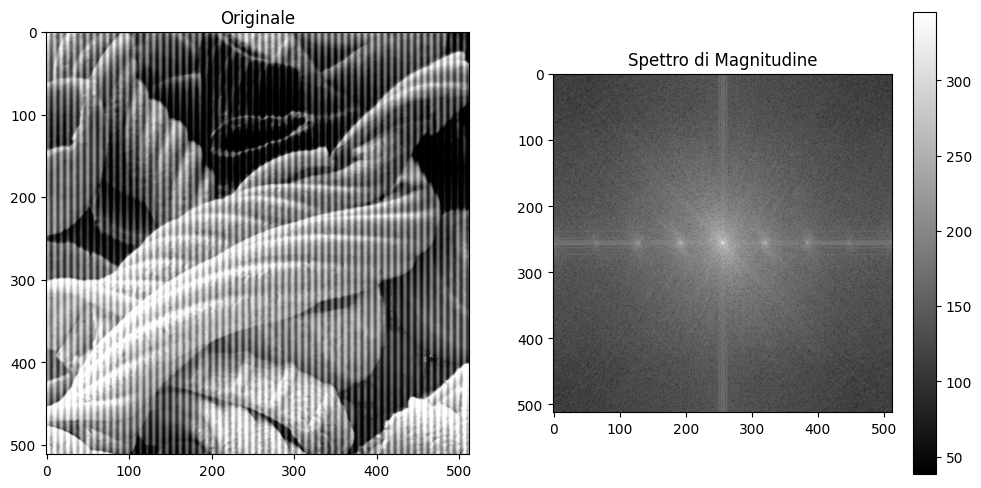

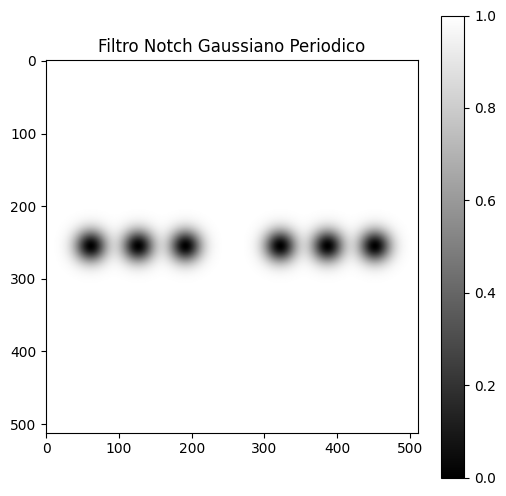

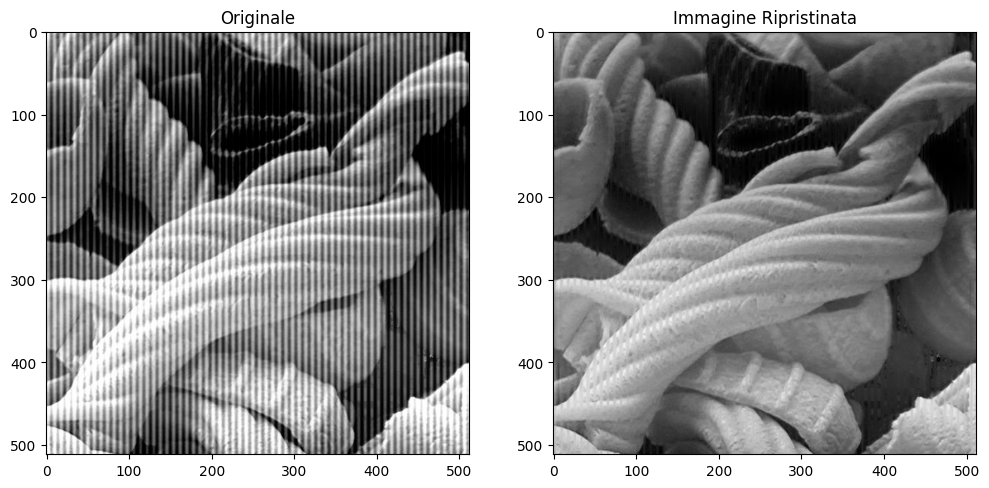

In [ ]:
im=cv2.imread('./data/img10.jpg')
im_gray=cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)
# Padding
padding_size = 256
im_gray_padded = np.pad(im_gray, ((padding_size, padding_size), (padding_size, padding_size)), mode='constant', constant_values=0)

# compute the 2D Fourier Transform
F2d = np.fft.fft2(im_gray_padded)
F2d_shifted = np.fft.fftshift(F2d)
magnitude_spectrum = 20 * np.log(np.abs(F2d_shifted) + 1)
plt.figure(figsize=(12, 6))
plt.subplot(121), plt.imshow(im_gray_padded, cmap='gray'), plt.title('Originale')
plt.subplot(122), plt.imshow(magnitude_spectrum, cmap='gray'), plt.title('Spettro di Magnitudine')
plt.colorbar()
plt.show()

rows, cols = im_gray_padded.shape
crow, ccol = rows // 2, cols // 2

u_dist = 65  # distanza dei picchi dal centro
sigma = 15.0  # controlla la morbidezza del notch gaussiano

# Griglia delle frequenze
U, V = np.meshgrid(np.arange(cols), np.arange(rows))

# Filtro notch gaussiano periodico 
H = np.ones((rows, cols), dtype=np.float32)

for i in range(1, cols // (2 * u_dist) + 1):
    shift = i * u_dist

    if ccol + shift < cols:
        D_pos = (U - (ccol + shift))**2 + (V - crow)**2
        notch_pos = 1 - np.exp(-D_pos / (2 * sigma**2))
        H *= notch_pos

    if ccol - shift >= 0:
        D_neg = (U - (ccol - shift))**2 + (V - crow)**2
        notch_neg = 1 - np.exp(-D_neg / (2 * sigma**2))
        H *= notch_neg

# plot the filter
plt.figure(figsize=(6, 6))
plt.imshow(H, cmap='gray')
plt.title('Filtro Notch Gaussiano Periodico')
plt.colorbar()
plt.show()

# Applicazione del filtro e antitrasformata
F_filtered = F2d_shifted * H
F_ishift = np.fft.ifftshift(F_filtered)
img_back = np.fft.ifft2(F_ishift)
img_back = np.abs(img_back)

plt.figure(figsize=(12, 6))
plt.subplot(121), plt.imshow(im_gray_padded, cmap='gray'), plt.title('Originale')
plt.subplot(122), plt.imshow(img_back, cmap='gray'), plt.title('Immagine Ripristinata')
plt.show()